# First thing First, let us downgrade our tensorflow

In [1]:
#Check tf version
import tensorflow as tf
print(tf.__version__)

#The following force you to use tensorflow 2.14 but you need to restart. You may comment it if you know you are using 2.14
#!pip3 install --upgrade tensorflow==2.14.0
print(tf.__version__)

2.17.0
2.17.0


#Some imports and GPU use. Google drive connect as well



In [5]:
#imports
import os
import numpy as np
import tensorflow as tf
tf.compat.v1.enable_eager_execution()
print('Eager execution:', tf.executing_eagerly())
print(tf.__version__)
import matplotlib.pyplot as plt
import datetime
import pickle
import pandas as pd
import random

#Connect to drive
from google.colab import drive
drive.mount('/content/drive') # mount drive


# set random seed to be used all over
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.compat.v1.set_random_seed(SEED)
config = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1,log_device_placement =True)
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(graph = tf.compat.v1.get_default_graph(), config = config)


Eager execution: True
2.17.0
Mounted at /content/drive
Device mapping: no known devices.


# Getting the dataset




In [3]:
import os
# Path to the directory containing the project files (CHANGE THIS PATH TO THE DIRECTORY ON YOUR COMPUTER)
PROJECT_ROOT_DIR = os.getcwd() + '/'

# Path to the directory containing the dataset relative to project file
DATA_DIR = 'drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/'

#path to the directory you want to use for saving models relative to the project file
MODEL_DIR = 'drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/'

In [4]:
# Funciton for loading the dataset
# Code from advml-traffic-sign (https://github.com/inspire-group/advml-traffic-sign)
def load_dataset_GTSRB(n_channel=3, train_file_name=None):
    """
    Load GTSRB data as a (datasize) x (channels) x (height) x (width) numpy
    matrix. Each pixel is rescaled to the range [0,1].
    """

    def load_pickled_data(file, columns):
        """
        Loads pickled training and test data.

        Parameters
        ----------
        file    : string
                          Name of the pickle file.
        columns : list of strings
                          List of columns in pickled data we're interested in.

        Returns
        -------
        A tuple of datasets for given columns.
        """

        with open(file, mode='rb') as f:
            dataset = pickle.load(f)
        return tuple(map(lambda c: dataset[c], columns))

    def preprocess(x, n_channel):
        """
        Preprocess dataset: turn images into grayscale if specified, normalize
        input space to [0,1], reshape array to appropriate shape for NN model
        """

        if n_channel == 3:
            # Scale features to be in [0, 1]
            x = (x / 255.).astype(np.float32)
        else:
            # Convert to grayscale, e.g. single Y channel
            x = 0.299 * x[:, :, :, 0] + 0.587 * x[:, :, :, 1] + \
                0.114 * x[:, :, :, 2]
            # Scale features to be in [0, 1]
            x = (x / 255.).astype(np.float32)
            x = x[:, :, :, np.newaxis]
        return x

    # Load pickle dataset
    if train_file_name is None:
        x_train, y_train = load_pickled_data(
            PROJECT_ROOT_DIR + DATA_DIR + 'train.p', ['features', 'labels'])
    else:
        x_train, y_train = load_pickled_data(
            PROJECT_ROOT_DIR + DATA_DIR + train_file_name, ['features', 'labels'])
    x_val, y_val = load_pickled_data(
        PROJECT_ROOT_DIR + DATA_DIR + 'valid.p', ['features', 'labels'])
    x_test, y_test = load_pickled_data(
        PROJECT_ROOT_DIR + DATA_DIR + 'test.p', ['features', 'labels'])

    # Preprocess loaded data
    x_train = preprocess(x_train, n_channel)
    x_val = preprocess(x_val, n_channel)
    x_test = preprocess(x_test, n_channel)
    return x_train, y_train, x_val, y_val, x_test, y_test

In [5]:
# Load the images and labels. These images are RGB so we have 3 channels
import os
import numpy as np
import tensorflow as tf
tf.compat.v1.enable_eager_execution()
print('Eager execution:', tf.executing_eagerly())
print(tf.__version__)
import matplotlib.pyplot as plt
import datetime
import pickle
import pandas as pd
import random

imgs_train, labels_train, imgs_val, labels_val, imgs_test, labels_test = load_dataset_GTSRB(n_channel=3)

Eager execution: True
2.17.0


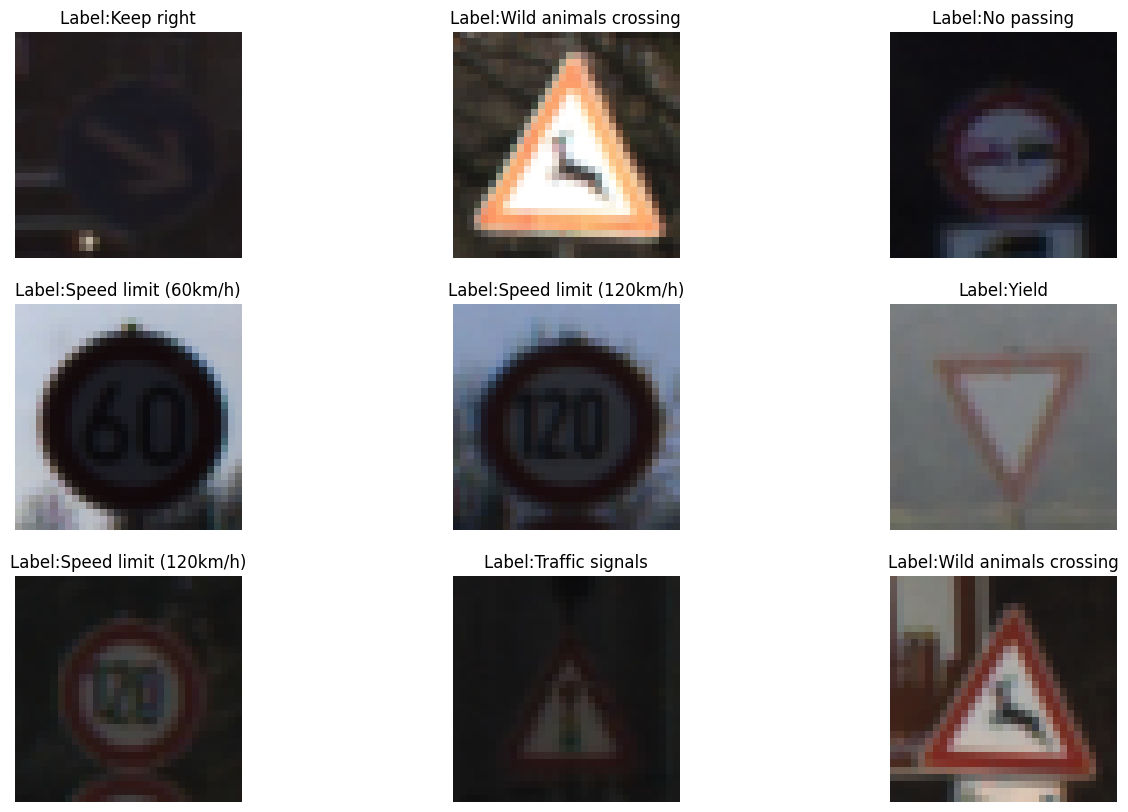

In [6]:
import pandas as pd
# Read the sign names
signnames = pd.read_csv(PROJECT_ROOT_DIR + '/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/signnames.csv').values[:, 1]

# Plot a few images to check if the data makes sense (note that the quality of some of the images is pretty low)
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(imgs_train), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(imgs_train[i[0]])
    plt.title('Label:' + str(signnames[labels_train[i[0]]]))
    plt.axis('off')

#Hyperparameters for training

In [7]:
# Set constants (GTSRB)
NUM_LABELS = 43                             # Number of labels or classes for classification
BATCH_SIZE = 128                            # Size of batch
HEIGHT = 32                                 # Height of input image
WIDTH = 32                                  # Width of input image
N_CHANNEL = 3                               # Number of channels
OUTPUT_DIM = 43                             # Number of output dimension

# Set training hyperparameters
NUM_EPOCH = 50                             # Number of epoch to train
LR = 0.0002                                 # Learning rate
RBW = True #restore best weights
PATIENCE = 5# how many epochs between improvements

INPUT_SHAPE = (HEIGHT, WIDTH, N_CHANNEL)  # Input shape of model
IMG_SHAPE = (HEIGHT, WIDTH, N_CHANNEL)

#Some preprocessing

In [8]:
#avoiding future overfitting
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [EarlyStopping(monitor='val_loss',
                   patience = PATIENCE,
                   restore_best_weights=RBW)]

In [9]:
# setting up labels
from tensorflow.keras.utils import to_categorical

#Convert the labels to one-hot encoding (to input to the models)

#make a copy of 500 test images before we encode for adversarial testing.
imgs_adv = imgs_test[0:500,:,:,:].copy()
labels_adv = labels_test[0:500].copy()




labels_train_cat = to_categorical(labels_train, NUM_LABELS)
labels_test_cat = to_categorical(labels_test, NUM_LABELS)
labels_val_cat = to_categorical(labels_val, NUM_LABELS)

#for testing adversarial inputs
labels_adv_cat = to_categorical(labels_adv,NUM_LABELS)

print('Labels train shape: {}'.format(labels_train.shape))
print('Labels train catagorical shape: {}\n'.format(labels_train_cat.shape))
print('Labels Adver shape: {}'.format(labels_adv.shape))
print('Labels Adver catagorical shape: {}'.format(labels_adv_cat.shape))

print('Imgs Adver shape: {}'.format(imgs_adv.shape))

Labels train shape: (34799,)
Labels train catagorical shape: (34799, 43)

Labels Adver shape: (500,)
Labels Adver catagorical shape: (500, 43)
Imgs Adver shape: (500, 32, 32, 3)


# Build our deep learning model


In [10]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model


#create our model
def build_model():
    #create VGG16 model with properties we want.
    base_model = tf.keras.applications.VGG16(include_top=False,
                                    weights="imagenet",
                                    input_shape=INPUT_SHAPE)

    #create fully connected layers
    #by not including the top we need to create these layers ourselves
    #input and output layers
    # Add a global spatial average pooling layer
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Add a fully-connected layer
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.25)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.25)(x)
    # Add a softmax layer with 43 classes
    predictions = Dense(OUTPUT_DIM, activation='softmax', name ='softmax')(x)

    # The model
    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
              loss='categorical_crossentropy',
              metrics = ['accuracy'])



    return model



In [ ]:
# Training the model

##It will take alot of time to train the model. Thus, uncomment the following, build the model, save it and comment it back in your next run
## the code to save the move is available next.
'''
model = build_model()

t = datetime.datetime.now()

#fit the model
history = model.fit(x= imgs_train,
    y= labels_train_cat,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCH,
    # monitoring validation loss and metrics
    validation_data=(imgs_val, labels_val_cat),
    verbose=1,
    callbacks=callbacks)

print('Training time: %s\n' % (datetime.datetime.now() - t))



# Evaluate on train,validation,test images
t = datetime.datetime.now()
evals_test = model.evaluate(imgs_test, labels_test_cat)
print("Classification Accuracy Test: ", evals_test[1])
print('Inference time: %s \n' % (datetime.datetime.now() - t))



t = datetime.datetime.now()
evals_test = model.evaluate(imgs_val, labels_val_cat)
print("Classification Accuracy Validation: ", evals_test[1])
print('Inference time: %s \n' % (datetime.datetime.now() - t))



t = datetime.datetime.now()
evals_test = model.evaluate(imgs_train, labels_train_cat)
print("Classification Accuracy Train: ", evals_test[1])
print('Inference time: %s' % (datetime.datetime.now() - t))
'''

In [11]:
## Load the saved the model
from tensorflow.keras.models import load_model


#The followiwng line should be uncommented with your first run (to save the model)
#model.save(MODEL_DIR +'VGG_best.keras')


#load our already trained model
# Your earlier directories should change to match this one
#You should be able to load the model once trained. The following line is used for that.
model = load_model( MODEL_DIR +'VGG_best.h5')



/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


##Task 1:  Untargeted attacks
# CS5331/CS4331 You should Impliment this part
Let’s start with basic non-target white-box attacks. First, we will implement some non-target white-box attacks we studied in class. Your downloaded code from Blackboard will build a VGG16 model for you. You will attack that deep learning model throughout the assignment.

This task aims to implement the following attacks: Fast Gradient Sign Method (FGSM), Projected Gradient Descent (PGD), Deep Fool, and C&W with L2 norm. You don’t need to implement these attacks from scratch. Code for them can be in several libraries, including Adversarial Robustness Toolbox (ART), cleverhans, or scratchai (Just traditional libraries. Maybe there are better ones now). Using ART for this assignment is recommended, but using any other libraries of your choice is also acceptable. This [notebook](https://https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/art-for-tensorflow-v2-keras.ipynb) is a good start on how to use ART, and multiple other notebooks are available here.

Your task is to apply attacks to create non-target adversarial examples using the first 500 images of your test set (check imgs_adv and labels_adv in your code). For FSGM, PGD, and DeepFool, apply perturbations magnitudes: 𝜖= [0.05, 0.1, 0.2, 0.25, 0.3]. For C&W, use the L2 norm to perform the attack. You should provide us with the following results.

Then

1- Plot the clean image vs adversarial image for three images of your choice

2- For two images of choice, plot the clean image vs. adversarial images of all attacks (if the perturbation is needed, choose 𝜖= [0.1]).

3- Fill out Table 1 and Table 2 for accuracy and add the noise of each attack.

4- Plot accuracy versus perturbation 𝜖 for FSGM and PGD adversarial attacks (similar to the example in the following figure).


In [2]:
#Install ART if you have not done that

#!pip install adversarial-robustness-toolbox

#!pip install adversarial-robustness-toolbox==1.17.0

#import art
#print(dir(art))  # To see available modules

#!pip list

!pip install adversarial-robustness-toolbox

#!pip uninstall adversarial-robustness-toolbox
#!pip install git+https://github.com/Trusted-AI/adversarial-robustness-toolbox.git

try:
    from art.estimators.classification import TensorFlowV2Classifier
    from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, DeepFool, CarliniL2Method
    from art.utils import to_categorical
    print("ART successfully imported")
except ImportError:
    print("Error importing ART. Please make sure it is installed correctly and restart the runtime if needed.")
    raise



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.5 MB/s eta 0:00:00
ART successfully imported


#Impliment and generate results for FGSM

Labels shape: (500,)


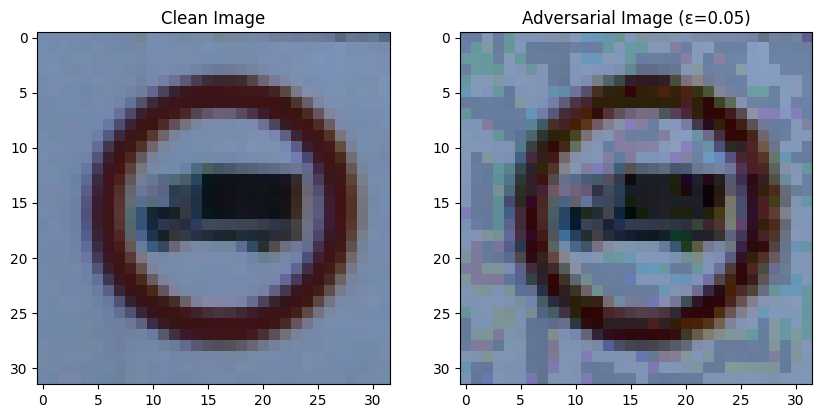

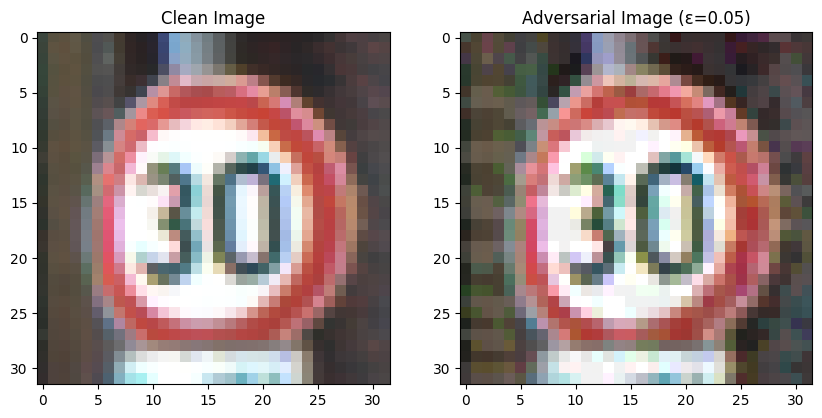

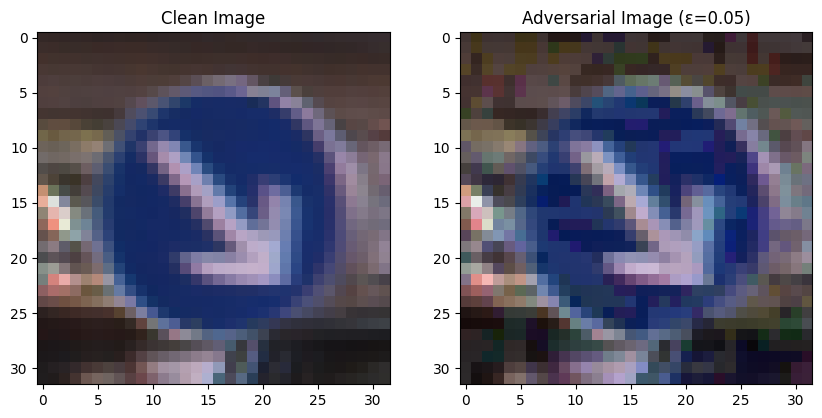

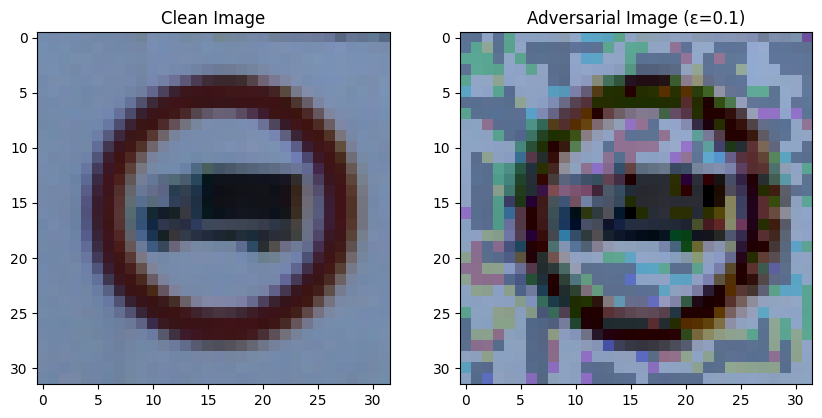

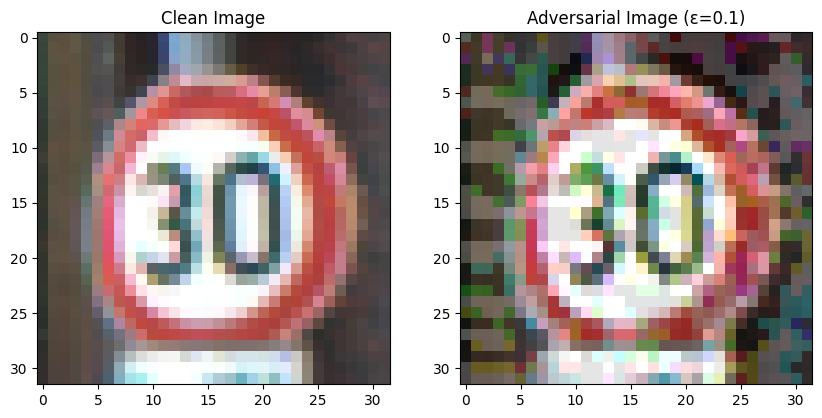

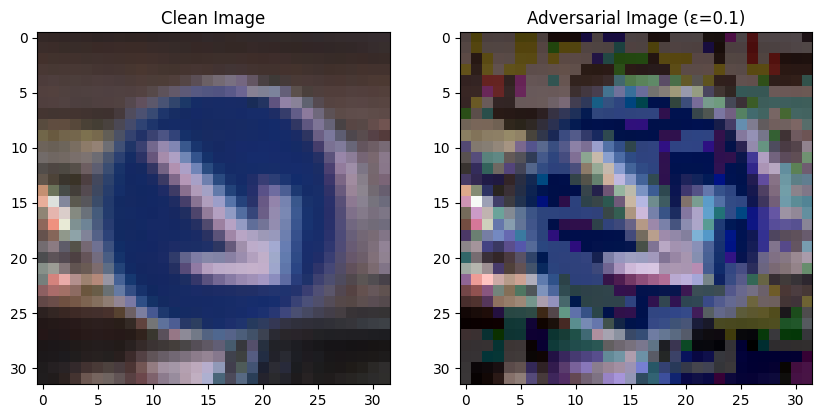

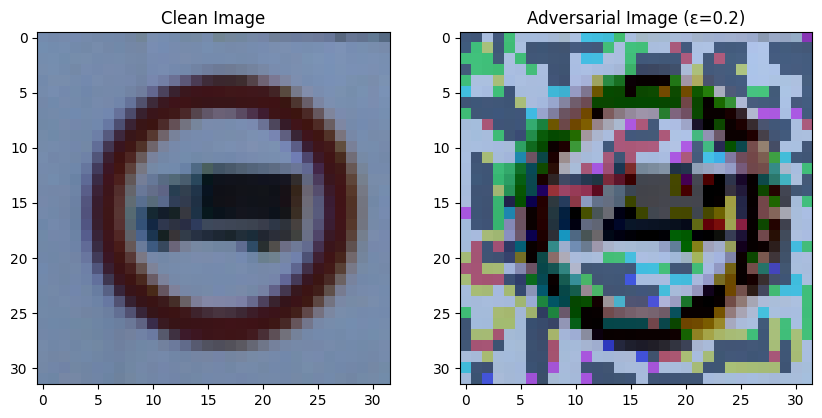

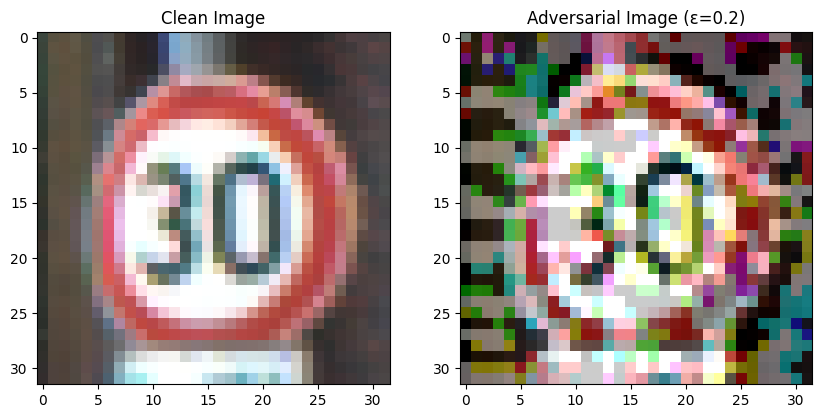

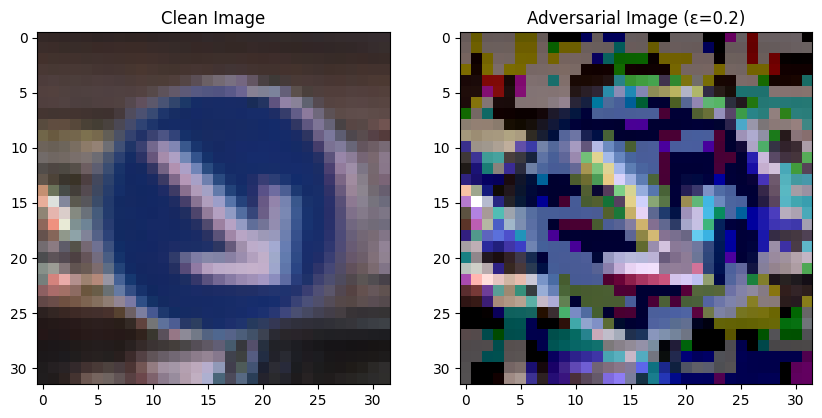

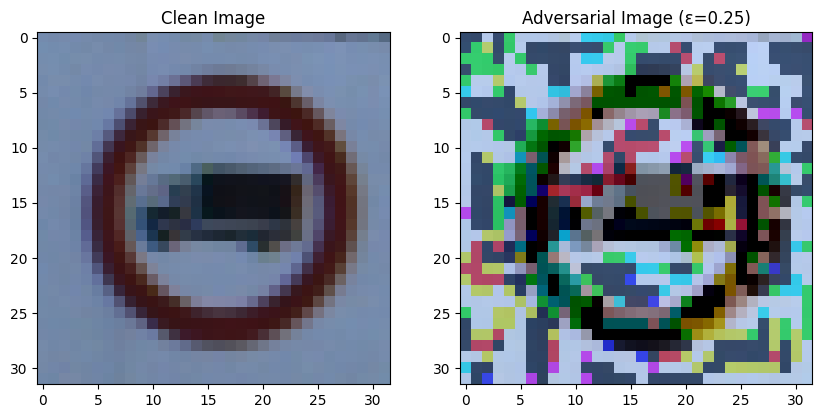

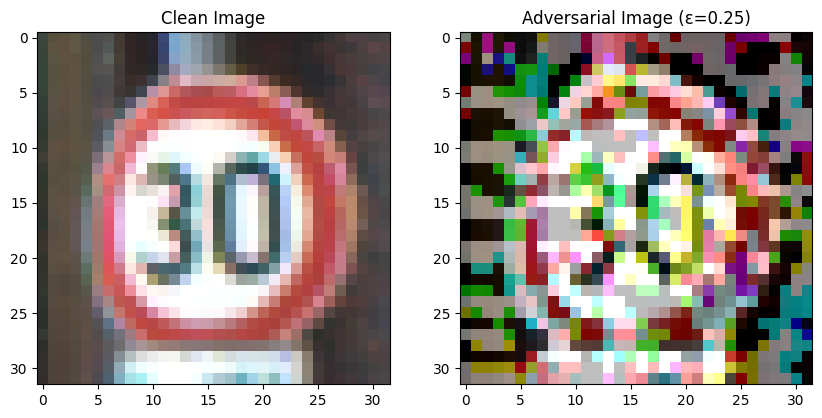

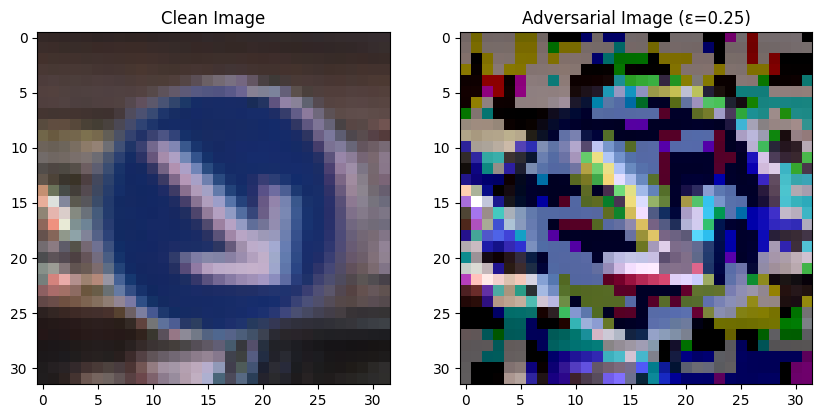

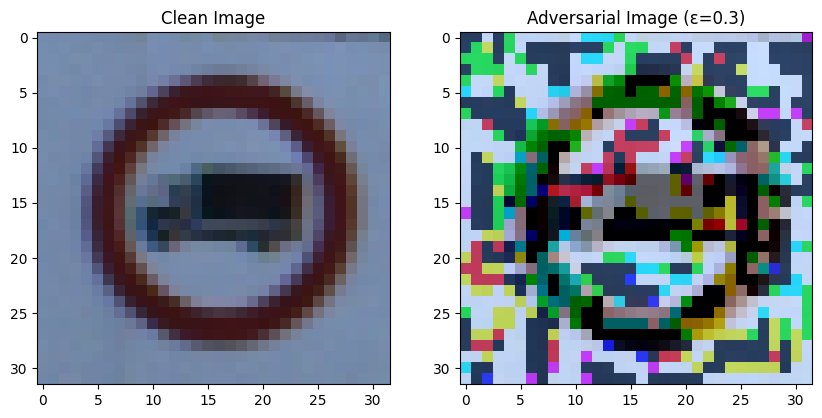

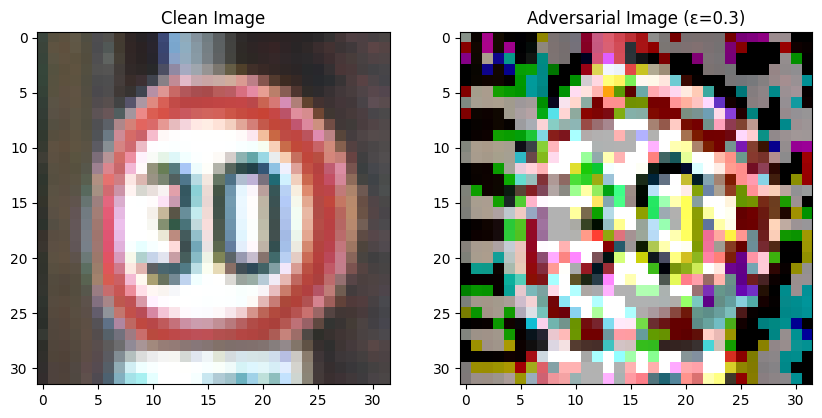

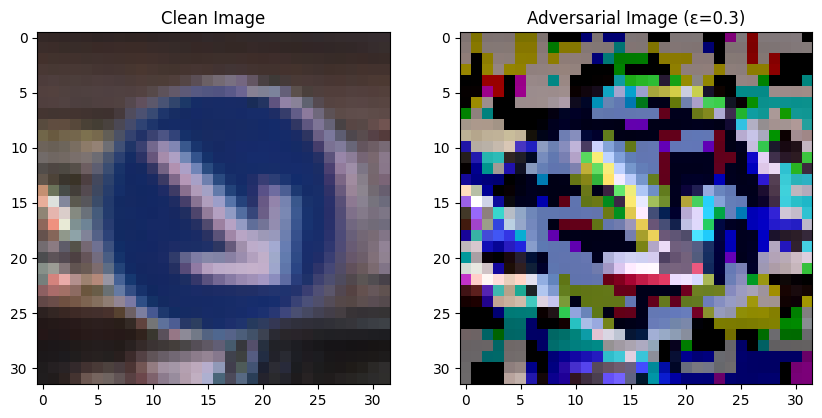

Accuracy on clean images: 0.9380
Accuracy on adversarial examples (ε=0.05): 0.2740
Accuracy on adversarial examples (ε=0.1): 0.2260
Accuracy on adversarial examples (ε=0.2): 0.1720
Accuracy on adversarial examples (ε=0.25): 0.1540
Accuracy on adversarial examples (ε=0.3): 0.1420
Average noise (ε=0.05): 0.0486
Average noise (ε=0.1): 0.0941
Average noise (ε=0.2): 0.1731
Average noise (ε=0.25): 0.2080
Average noise (ε=0.3): 0.2406


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod
import matplotlib.pyplot as plt

# Load the dataset and model
x_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/test.p', allow_pickle=True)
y_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/train.p', allow_pickle=True)
model = load_model('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/VGG_best.h5')

# Use only the first 500 images
images = x_test['features'][:500].astype(np.float32) / 255.0  # Normalize images to [0, 1]
labels = x_test['labels'][:500]

# Check the shape of y_test
print(f'Labels shape: {labels.shape}')

# Create the ART classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=43,  # Adjust for 43 classes in GTSRB dataset
    input_shape=x_test['features'][0].shape,  # Get shape of one image
    loss_object=tf.keras.losses.CategoricalCrossentropy(from_logits=False),  # Ensure from_logits=False if your model has softmax output
    clip_values=(0, 1)  # Images are now normalized to [0, 1]
)

# Define epsilon values
epsilons = [0.05, 0.1, 0.2, 0.25, 0.3]

# FGSM attack for multiple epsilon values and store adversarial examples
adversarial_examples = {}

for eps in epsilons:
    fgsm = FastGradientMethod(estimator=classifier, eps=eps)
    x_adv = fgsm.generate(x=images)
    adversarial_examples[eps] = x_adv  # Store adversarial examples for each epsilon

# Function to generate adversarial example with proper label shape (for manual generation)
def generate_adversarial_example(model, image, label, epsilon):
    label = tf.convert_to_tensor([label], dtype=tf.int64)  # Convert label to tensor and ensure correct shape
    image_tensor = tf.convert_to_tensor(image.reshape(1, 32, 32, 3), dtype=tf.float32)  # Ensure it's float32

    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        prediction = model(image_tensor)  # Model prediction
        loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)  # Sparse categorical loss

    # Calculate the gradient
    gradient = tape.gradient(loss, image_tensor)

    # Create the adversarial image using FGSM
    adversarial_image = image + epsilon * tf.sign(gradient.numpy())  # Add the sign of gradient * epsilon

    # Clip the adversarial image to [0, 1]
    return np.clip(adversarial_image, 0, 1)

# Generate adversarial examples for the first 500 images manually for comparison
x_test_adv_manual = np.array([generate_adversarial_example(model, img, lbl, epsilon=0.1) for img, lbl in zip(images, labels)])

# Function to plot clean vs adversarial images
def plot_images(clean, adv, index, epsilon):
    plt.figure(figsize=(10, 5))

    # Plot clean image
    plt.subplot(1, 2, 1)
    plt.imshow(clean[index])
    plt.title("Clean Image")

    # Plot adversarial image
    plt.subplot(1, 2, 2)
    plt.imshow(np.squeeze(adv[index]))  # Squeeze to remove extra dimension (if any)
    plt.title(f"Adversarial Image (ε={epsilon})")

    plt.show()

# Plot clean vs adversarial for three images for each epsilon value
for eps in epsilons:
    for i in range(3):
        plot_images(images, adversarial_examples[eps], i, eps)

# Accuracy on clean images
clean_predictions = classifier.predict(images)
clean_accuracy = np.mean(np.argmax(clean_predictions, axis=1) == labels)
print(f"Accuracy on clean images: {clean_accuracy:.4f}")

# Calculate accuracy on adversarial examples for each epsilon
for eps, x_adv in adversarial_examples.items():
    predictions = classifier.predict(x_adv)
    accuracy = np.mean(np.argmax(predictions, axis=1) == labels)
    print(f"Accuracy on adversarial examples (ε={eps}): {accuracy:.4f}")

# Calculate average noise for each epsilon
for eps, x_adv in adversarial_examples.items():
    noise = np.mean(np.abs(x_adv - images))
    print(f"Average noise (ε={eps}): {noise:.4f}")


#Impliment and generate results for PGD

Labels shape: (500,)


PGD - Batches: 0it [00:00, ?it/s]

PGD - Batches: 0it [00:00, ?it/s]

PGD - Batches: 0it [00:00, ?it/s]

PGD - Batches: 0it [00:00, ?it/s]

PGD - Batches: 0it [00:00, ?it/s]

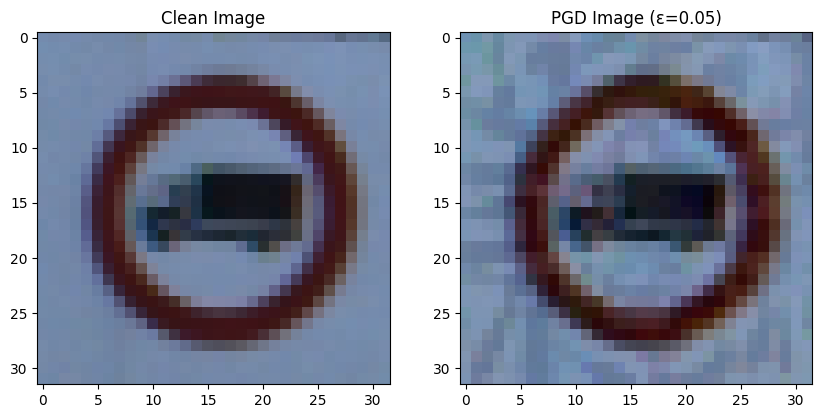

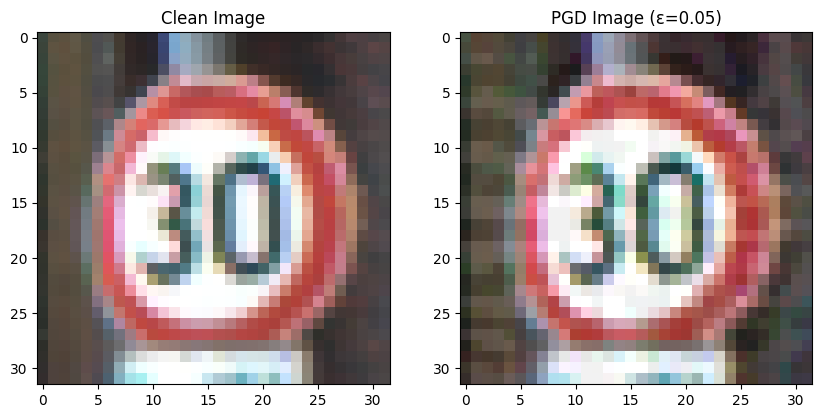

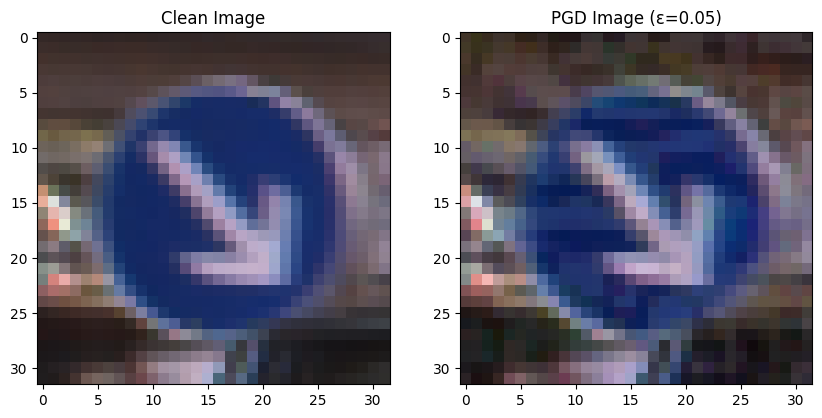

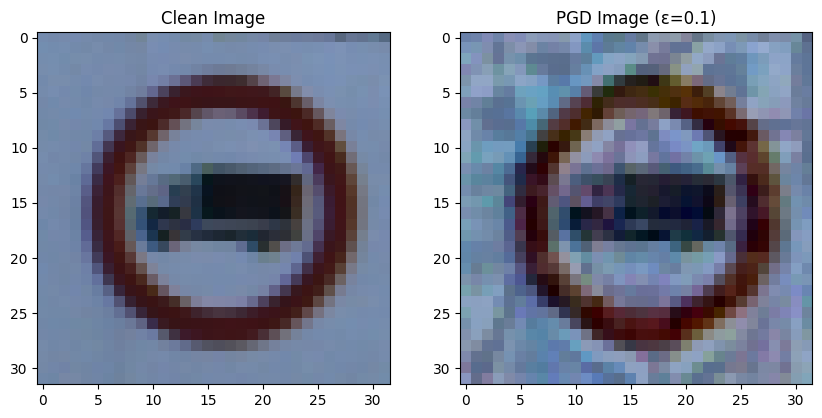

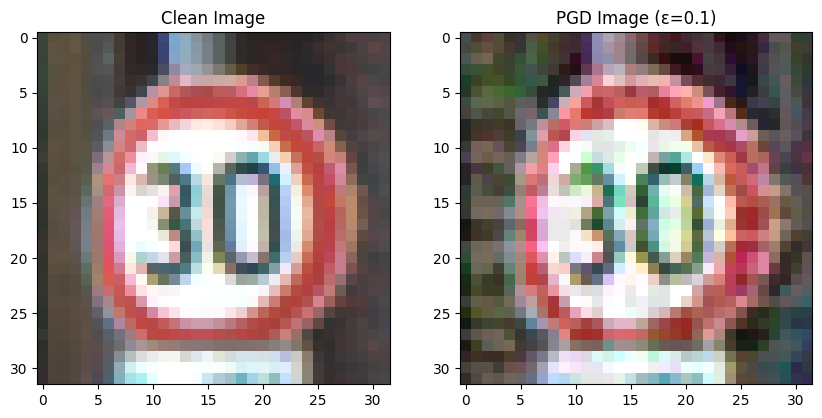

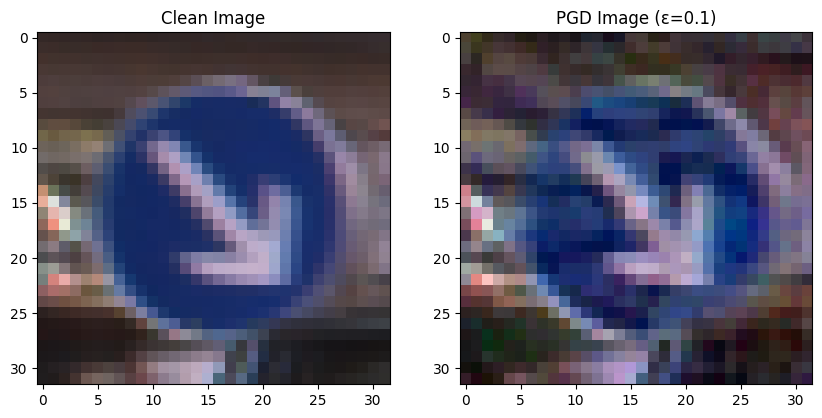

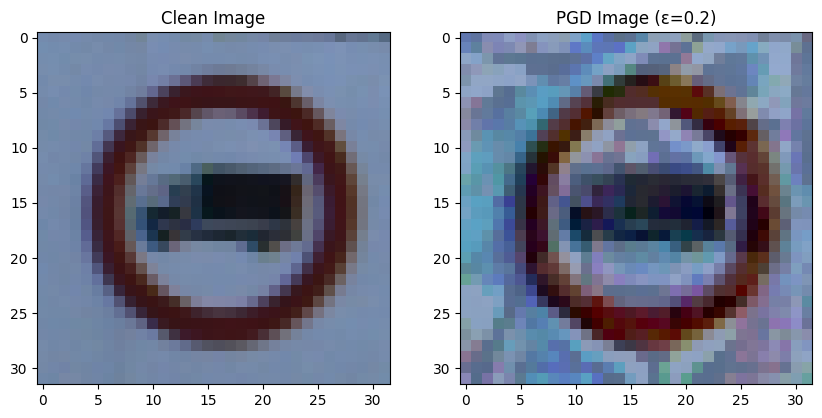

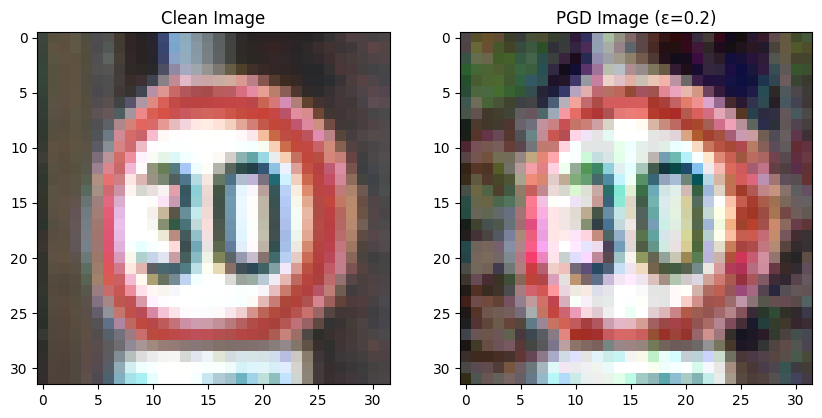

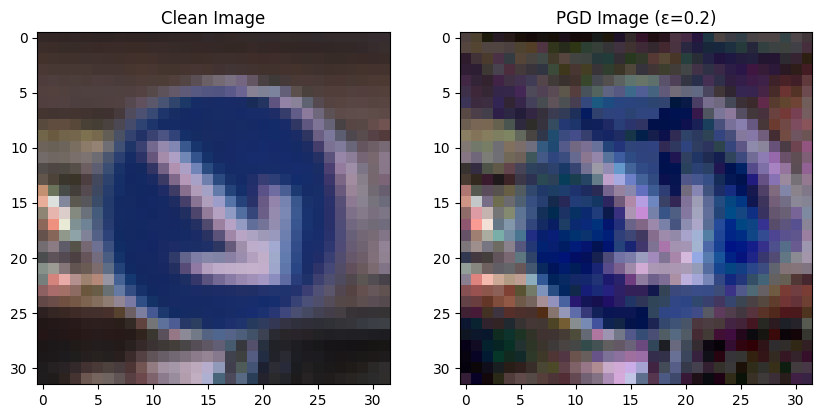

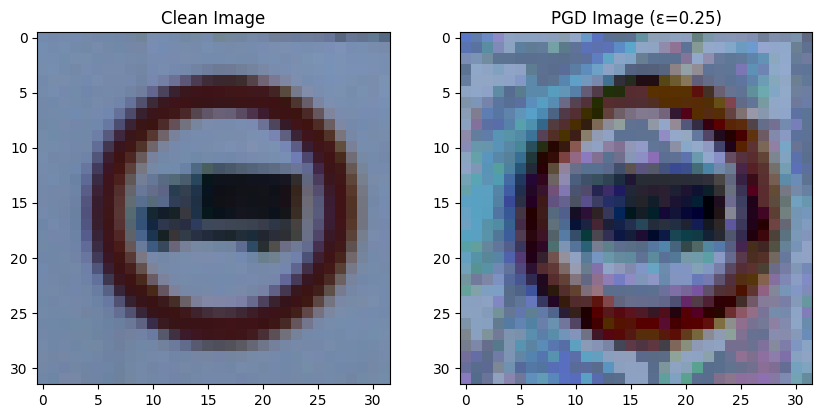

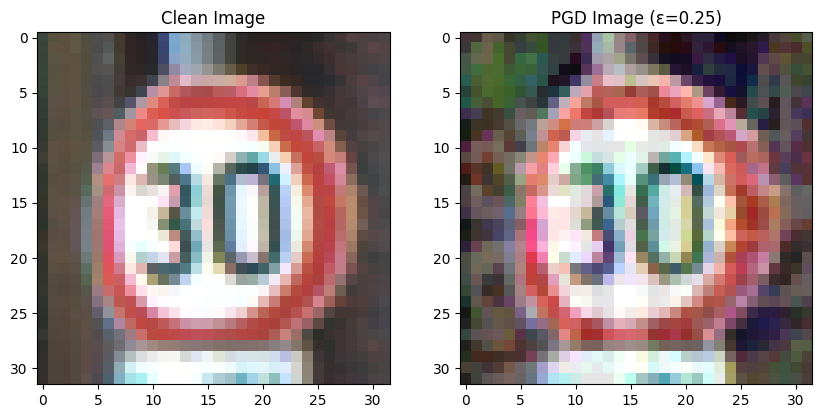

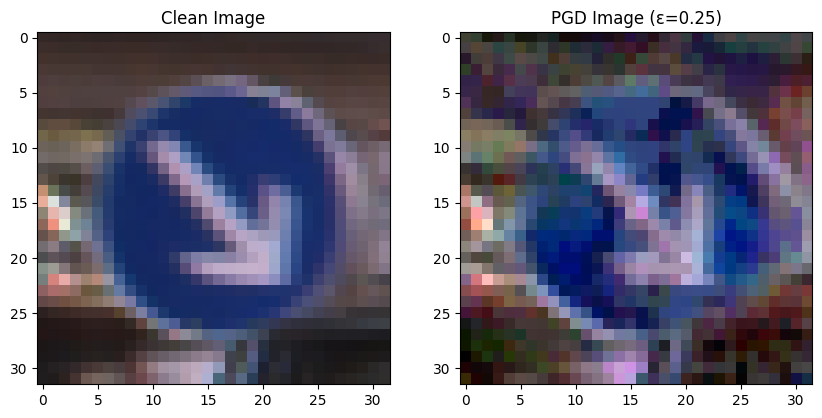

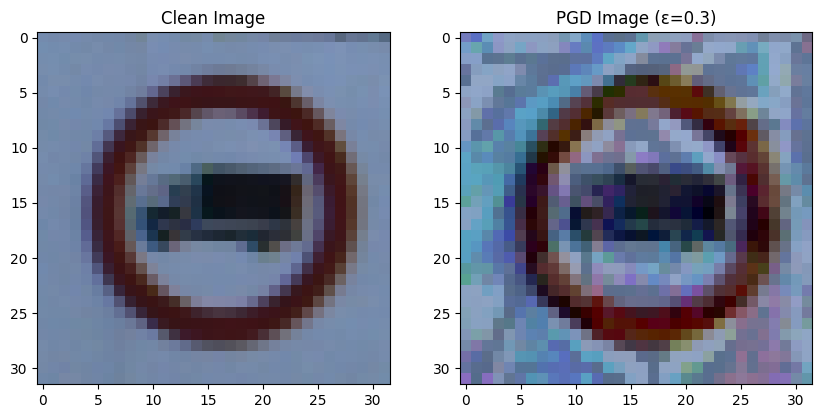

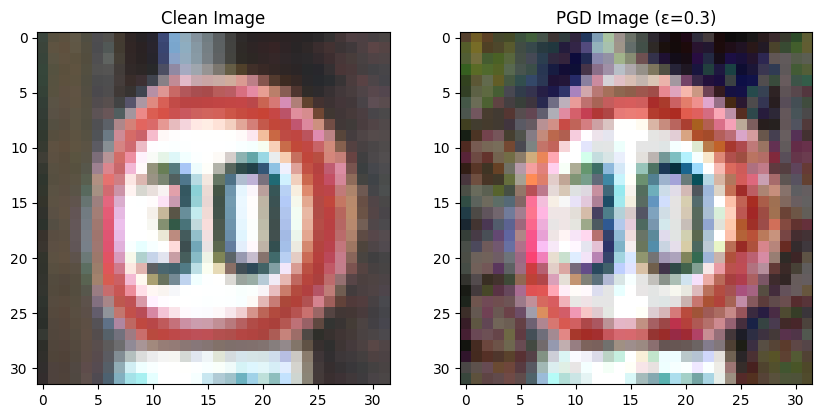

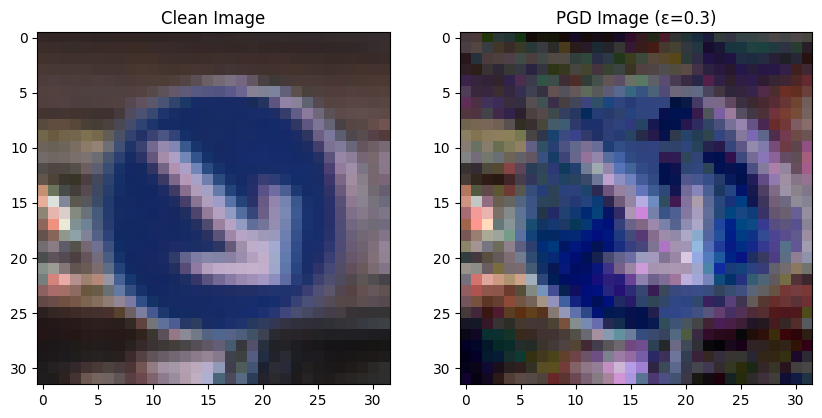

Accuracy on clean images: 0.9380
Accuracy on PGD adversarial examples (ε=0.05): 0.1840
Accuracy on PGD adversarial examples (ε=0.1): 0.1440
Accuracy on PGD adversarial examples (ε=0.2): 0.1280
Accuracy on PGD adversarial examples (ε=0.25): 0.1260
Accuracy on PGD adversarial examples (ε=0.3): 0.1260
Average noise (PGD, ε=0.05): 0.0273
Average noise (PGD, ε=0.1): 0.0437
Average noise (PGD, ε=0.2): 0.0577
Average noise (PGD, ε=0.25): 0.0613
Average noise (PGD, ε=0.3): 0.0626


In [ ]:
#Get your correct imports

#Create the ART classifier

#Create the ART attacker

#Generate your adv. samples

#Generate the results

#Save the results

#show figures for different eps



import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
import matplotlib.pyplot as plt

# Load the dataset and model
x_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/test.p', allow_pickle=True)
y_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/train.p', allow_pickle=True)
model = load_model('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/VGG_best.h5')

# Use only the first 500 images
images = x_test['features'][:500].astype(np.float32) / 255.0  # Normalize images to [0, 1]
labels = x_test['labels'][:500]

# Check the shape of y_test
print(f'Labels shape: {labels.shape}')

# Create the ART classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=43,  # Adjust for 43 classes in GTSRB dataset
    input_shape=x_test['features'][0].shape,  # Get shape of one image
    loss_object=tf.keras.losses.CategoricalCrossentropy(from_logits=False),  # Ensure from_logits=False if your model has softmax output
    clip_values=(0, 1)  # Images are now normalized to [0, 1]
)

# Define epsilon values for FGSM and PGD
epsilons = [0.05, 0.1, 0.2, 0.25, 0.3]
pgd_steps = 10  # Number of steps for the PGD attack
pgd_eps = 0.1   # Maximum perturbation for PGD

# FGSM attack for multiple epsilon values and store adversarial examples
"""adversarial_examples_fgsm = {}
for eps in epsilons:
    fgsm = FastGradientMethod(estimator=classifier, eps=eps)
    x_adv = fgsm.generate(x=images)
    adversarial_examples_fgsm[eps] = x_adv  # Store adversarial examples for each epsilon"""

# PGD attack for multiple epsilon values
adversarial_examples_pgd = {}
for eps in epsilons:
    pgd = ProjectedGradientDescent(estimator=classifier, eps=pgd_eps, eps_step=eps / pgd_steps, max_iter=pgd_steps)
    x_adv = pgd.generate(x=images)
    adversarial_examples_pgd[eps] = x_adv  # Store PGD adversarial examples

"""# Function to generate adversarial example with proper label shape (for manual generation)
def generate_adversarial_example(model, image, label, epsilon):
    label = tf.convert_to_tensor([label], dtype=tf.int64)  # Convert label to tensor and ensure correct shape
    image_tensor = tf.convert_to_tensor(image.reshape(1, 32, 32, 3), dtype=tf.float32)  # Ensure it's float32

    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        prediction = model(image_tensor)  # Model prediction
        loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)  # Sparse categorical loss

    # Calculate the gradient
    gradient = tape.gradient(loss, image_tensor)

    # Create the adversarial image using FGSM
    adversarial_image = image + epsilon * tf.sign(gradient.numpy())  # Add the sign of gradient * epsilon

    # Clip the adversarial image to [0, 1]
    return np.clip(adversarial_image, 0, 1)

# Generate adversarial examples for the first 500 images manually for comparison
x_test_adv_manual = np.array([generate_adversarial_example(model, img, lbl, epsilon=0.1) for img, lbl in zip(images, labels)])"""

# Function to plot clean vs adversarial images
def plot_images(clean, adv, index, epsilon, attack_type):
    plt.figure(figsize=(10, 5))

    # Plot clean image
    plt.subplot(1, 2, 1)
    plt.imshow(clean[index])
    plt.title("Clean Image")

    # Plot adversarial image
    plt.subplot(1, 2, 2)
    plt.imshow(np.squeeze(adv[index]))  # Squeeze to remove extra dimension (if any)
    plt.title(f"{attack_type} Image (ε={epsilon})")

    plt.show()

"""# Plot clean vs adversarial for three images for each epsilon value for FGSM
for eps in epsilons:
    for i in range(3):
        plot_images(images, adversarial_examples_fgsm[eps], i, eps, "FGSM")"""

# Plot clean vs adversarial for three images for each epsilon value for PGD
for eps in epsilons:
    for i in range(3):
        plot_images(images, adversarial_examples_pgd[eps], i, eps, "PGD")

# Accuracy on clean images
clean_predictions = classifier.predict(images)
clean_accuracy = np.mean(np.argmax(clean_predictions, axis=1) == labels)
print(f"Accuracy on clean images: {clean_accuracy:.4f}")

"""# Calculate accuracy on adversarial examples for each epsilon for FGSM
for eps, x_adv in adversarial_examples_fgsm.items():
    predictions = classifier.predict(x_adv)
    accuracy = np.mean(np.argmax(predictions, axis=1) == labels)
    print(f"Accuracy on FGSM adversarial examples (ε={eps}): {accuracy:.4f}")"""

# Calculate accuracy on adversarial examples for each epsilon for PGD
for eps, x_adv in adversarial_examples_pgd.items():
    predictions = classifier.predict(x_adv)
    accuracy = np.mean(np.argmax(predictions, axis=1) == labels)
    print(f"Accuracy on PGD adversarial examples (ε={eps}): {accuracy:.4f}")

"""# Calculate average noise for each epsilon for FGSM
for eps, x_adv in adversarial_examples_fgsm.items():
    noise = np.mean(np.abs(x_adv - images))
    print(f"Average noise (FGSM, ε={eps}): {noise:.4f}")"""

# Calculate average noise for each epsilon for PGD
for eps, x_adv in adversarial_examples_pgd.items():
    noise = np.mean(np.abs(x_adv - images))
    print(f"Average noise (PGD, ε={eps}): {noise:.4f}")


#Impliment and generate results for Deep fool



In [ ]:
#Get your correct imports

#Create the ART classifier

#Create the ART attacker

#Generate your adv. samples

#Generate the results

#Save the results

#show figures for different eps

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import DeepFool
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive') # mount drive


# Load the dataset and model
x_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/test.p', allow_pickle=True)
y_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/train.p', allow_pickle=True)
model = load_model('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/VGG_best.h5')

# Use only the first 500 images
images = x_test['features'][:500].astype(np.float32) / 255.0  # Normalize images to [0, 1]
labels = x_test['labels'][:500]

# Create the ART classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=43,  # Adjust for 43 classes in GTSRB dataset
    input_shape=x_test['features'][0].shape,  # Get shape of one image
    loss_object=tf.keras.losses.CategoricalCrossentropy(from_logits=False),  # Ensure from_logits=False if your model has softmax output
    clip_values=(0, 1)  # Images are now normalized to [0, 1]
)

# Define epsilon values for DeepFool
epsilons = [0.05, 0.1, 0.2, 0.25, 0.3]

# Store adversarial examples for each epsilon
adversarial_examples_deepfool = {}

# DeepFool attack for multiple epsilon values
for eps in epsilons:
    deepfool = DeepFool(classifier)  # Use the current epsilon as overshoot
    x_adv = deepfool.generate(x=images, eps=eps)
    adversarial_examples_deepfool[eps] = x_adv  # Store adversarial examples for each epsilon

# Function to plot clean vs adversarial images
def plot_images(clean, adv, index, epsilon):
    plt.figure(figsize=(10, 5))

    # Plot clean image
    plt.subplot(1, 2, 1)
    plt.imshow(clean[index])
    plt.title("Clean Image")

    # Plot adversarial image
    plt.subplot(1, 2, 2)
    plt.imshow(np.squeeze(adv[index]))  # Squeeze to remove extra dimension (if any)
    plt.title(f"DeepFool Adversarial Image (ε={epsilon})")

    plt.show()

# Plot clean vs adversarial for three images for each epsilon value
for eps in epsilons:
    for i in range(3):
        plot_images(images, adversarial_examples_deepfool[eps], i, eps)

# Accuracy on clean images
clean_predictions = classifier.predict(images)
clean_accuracy = np.mean(np.argmax(clean_predictions, axis=1) == labels)
print(f"Accuracy on clean images: {clean_accuracy:.4f}")

# Calculate accuracy on adversarial examples for each epsilon from DeepFool
for eps, x_adv in adversarial_examples_deepfool.items():
    predictions = classifier.predict(x_adv)
    accuracy = np.mean(np.argmax(predictions, axis=1) == labels)
    print(f"Accuracy on DeepFool adversarial examples (ε={eps}): {accuracy:.4f}")

# Calculate average noise for each epsilon from DeepFool
for eps, x_adv in adversarial_examples_deepfool.items():
    noise = np.mean(np.abs(x_adv - images))
    print(f"Average noise (DeepFool, ε={eps}): {noise:.4f}")


#Impliment and generate results for C&W2

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


C&W L_2:   0%|          | 0/150 [00:00<?, ?it/s]

C&W L_2:   0%|          | 0/150 [00:00<?, ?it/s]

C&W L_2:   0%|          | 0/150 [00:00<?, ?it/s]

C&W L_2:   0%|          | 0/150 [00:00<?, ?it/s]

C&W L_2:   0%|          | 0/150 [00:00<?, ?it/s]

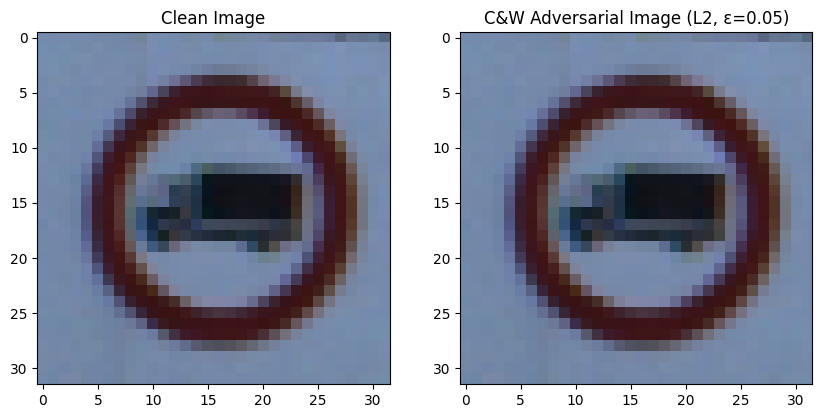

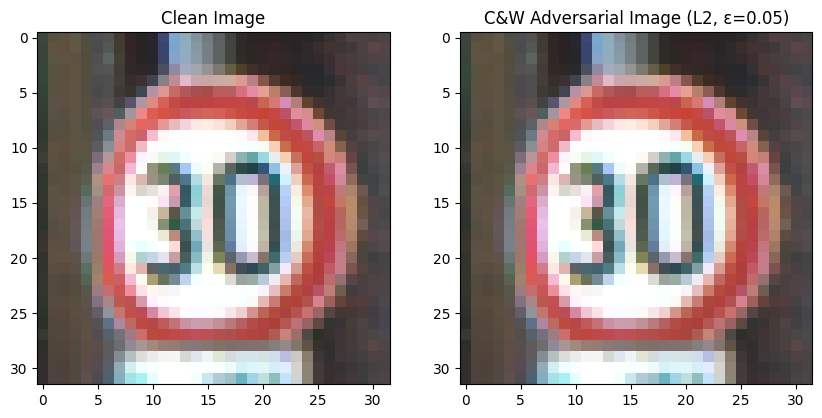

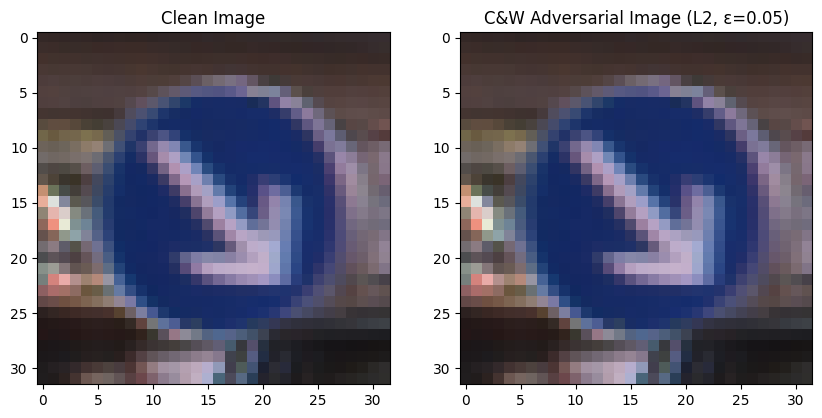

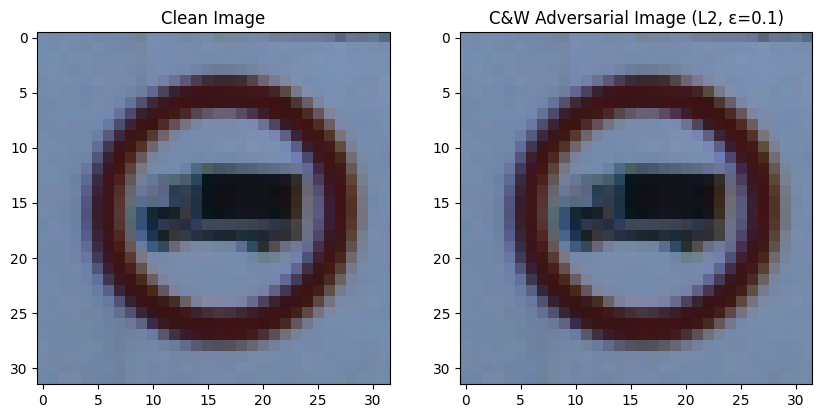

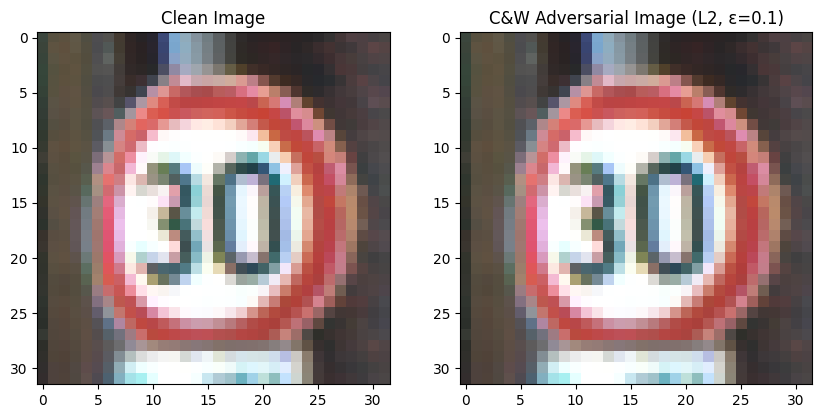

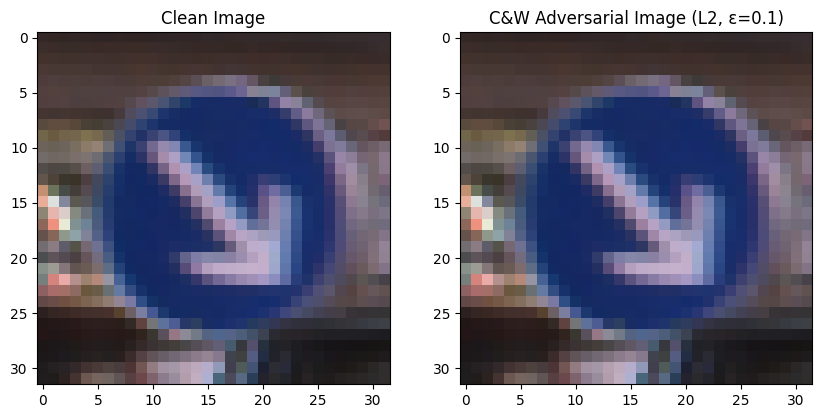

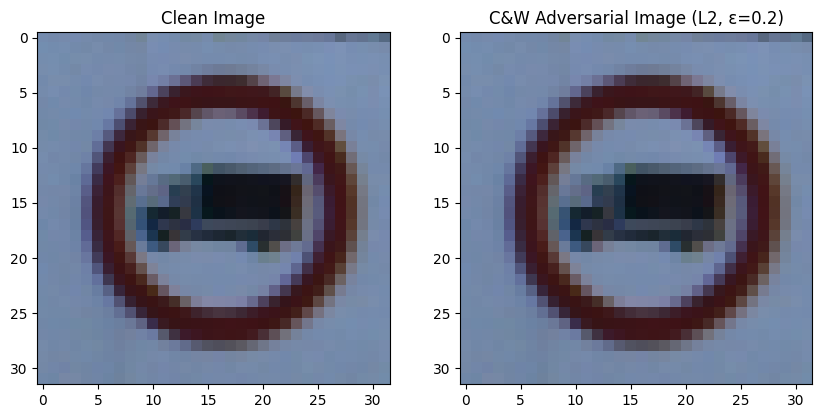

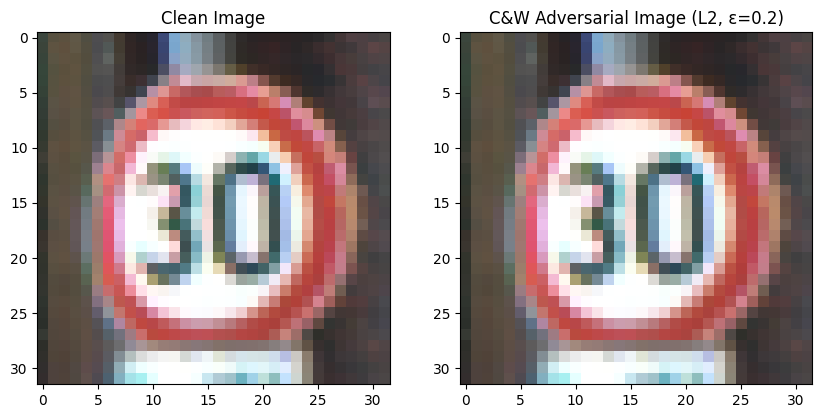

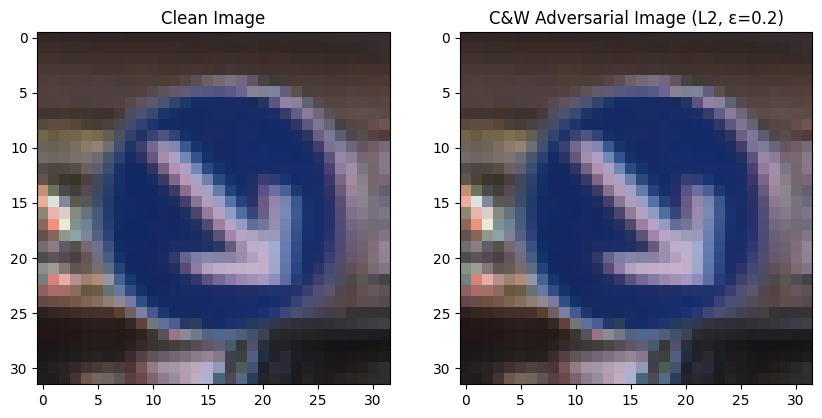

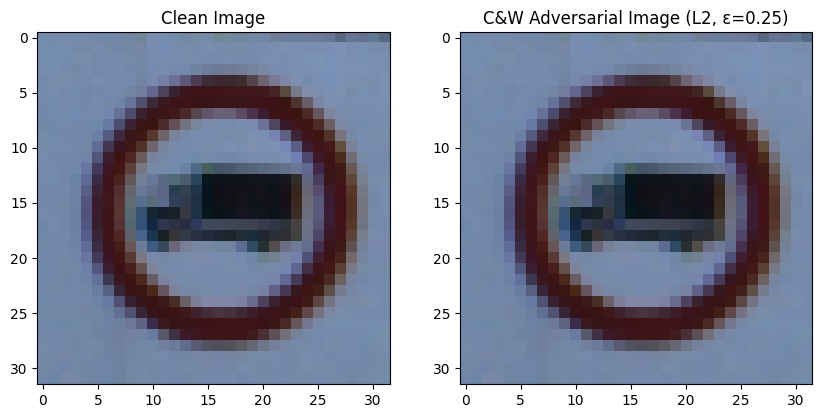

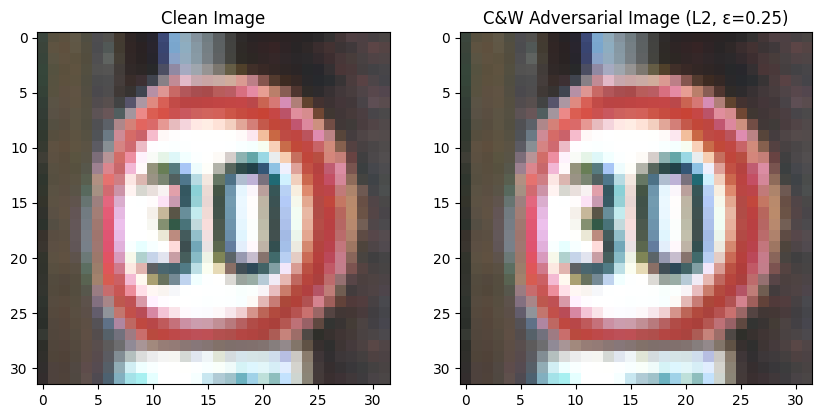

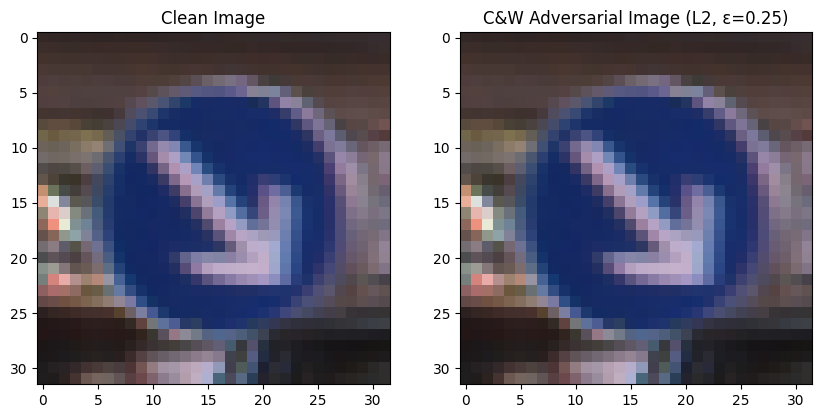

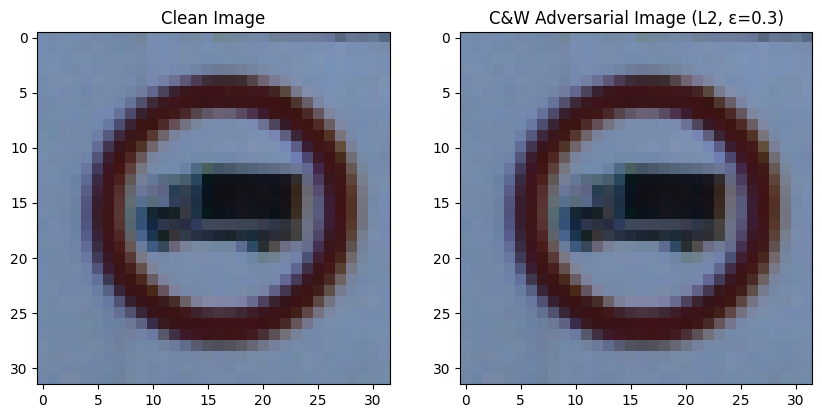

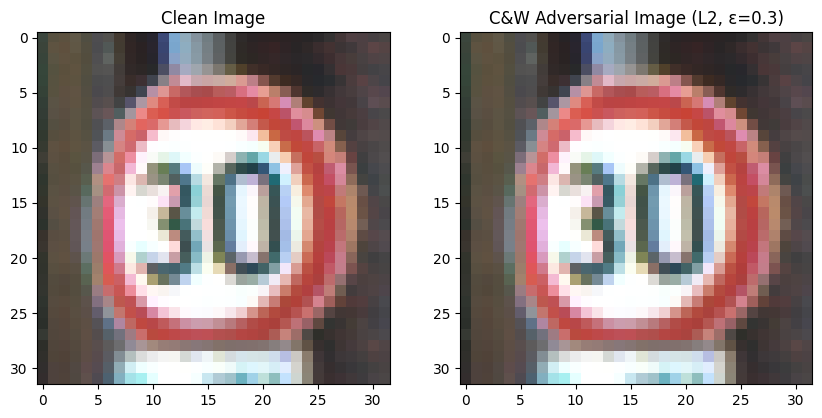

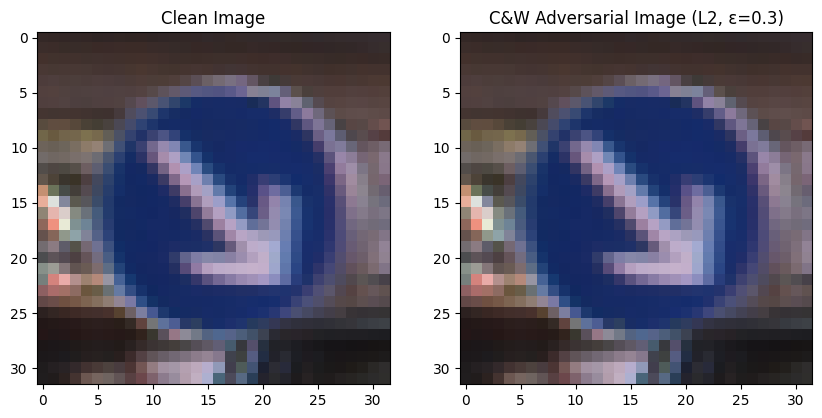

Accuracy on clean images: 0.9333
Average noise (C&W, L2, ε=0.05): 0.0001
Accuracy on C&W adversarial examples (L2, ε=0.05): 0.8267
Average noise (C&W, L2, ε=0.1): 0.0001
Accuracy on C&W adversarial examples (L2, ε=0.1): 0.8267
Average noise (C&W, L2, ε=0.2): 0.0002
Accuracy on C&W adversarial examples (L2, ε=0.2): 0.8267
Average noise (C&W, L2, ε=0.25): 0.0001
Accuracy on C&W adversarial examples (L2, ε=0.25): 0.8333
Average noise (C&W, L2, ε=0.3): 0.0001
Accuracy on C&W adversarial examples (L2, ε=0.3): 0.8400
Results saved to cw_results.csv


In [6]:
#Do the same for C&W
#Make sure you are using L2 norm


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import CarliniL2Method
import matplotlib.pyplot as plt

# Load the dataset and model
x_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/test.p', allow_pickle=True)
y_test = np.load('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/train.p', allow_pickle=True)
model = load_model('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/VGG_best.h5')

# Use only the first 500 images
images = x_test['features'][:150].astype(np.float32) / 255.0  # Normalize images to [0, 1]
labels = x_test['labels'][:150]

# Create the ART classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=43,  # Adjust for 43 classes in GTSRB dataset
    input_shape=x_test['features'][0].shape,  # Get shape of one image
    loss_object=tf.keras.losses.CategoricalCrossentropy(from_logits=False),  # Ensure from_logits=False if your model has softmax output
    clip_values=(0, 1)  # Images are now normalized to [0, 1]
)

# Define epsilon values for C&W attack
epsilons = [0.05, 0.1, 0.2, 0.25, 0.3]

# Store adversarial examples for each epsilon
adversarial_examples_cw = {}

# C&W attack for multiple epsilon values
for eps in epsilons:
    cw = CarliniL2Method(classifier, targeted=False, max_iter=1, confidence=eps, learning_rate=0.01)
    x_adv = cw.generate(x=images, y=labels)  # Generate adversarial examples
    adversarial_examples_cw[eps] = x_adv  # Store adversarial examples for each epsilon

# Function to plot clean vs adversarial images
def plot_images(clean, adv, index, epsilon):
    plt.figure(figsize=(10, 5))

    # Plot clean image
    plt.subplot(1, 2, 1)
    plt.imshow(clean[index])
    plt.title("Clean Image")

    # Plot adversarial image
    plt.subplot(1, 2, 2)
    plt.imshow(np.squeeze(adv[index]))  # Squeeze to remove extra dimension (if any)
    plt.title(f"C&W Adversarial Image (L2, ε={epsilon})")

    plt.show()

# Plot clean vs adversarial for three images for each epsilon value
for eps in epsilons:
    for i in range(3):
        plot_images(images, adversarial_examples_cw[eps], i, eps)

# Accuracy on clean images
clean_predictions = classifier.predict(images)
clean_accuracy = np.mean(np.argmax(clean_predictions, axis=1) == labels)
print(f"Accuracy on clean images: {clean_accuracy:.4f}")

results = {'epsilon': [], 'accuracy': [], 'average_noise': []}

# Calculate accuracy on adversarial examples for each epsilon from C&W
for eps, x_adv in adversarial_examples_cw.items():
    predictions = classifier.predict(x_adv)
    accuracy = np.mean(np.argmax(predictions, axis=1) == labels)
    results['epsilon'].append(eps)
    results['accuracy'].append(accuracy)
    noise = np.mean(np.abs(x_adv - images))
    results['average_noise'].append(noise)

    print(f"Average noise (C&W, L2, ε={eps}): {noise:.4f}")
    print(f"Accuracy on C&W adversarial examples (L2, ε={eps}): {accuracy:.4f}")

# Calculate average noise for each epsilon from C&W
"""for eps, x_adv in adversarial_examples_cw.items():
    noise = np.mean(np.abs(x_adv - images))
    print(f"Average noise (C&W, L2, ε={eps}): {noise:.4f}")"""


results_df = pd.DataFrame(results)

# Save results to a CSV file
results_df.to_csv('/content/drive/MyDrive/CS5331_CS4331/HW1/GTSRB_dataset/cw_results.csv', index=False)
print("Results saved to cw_results.csv")


##Task 2 targeted attacks

Now, let’s do some target attacks with white-box assumptions. Use the images with the Stop sign (label 14) from the overall test set for this task. There are around 270 images of that kind. Implement FGSM attacks on the Stop sign images to misclassify them as speed 30 sign images (label 1). Apply perturbations magnitudes: 𝜖= [0.05, 0.1, 0.2, 0.25, 0.3] for these attacks and report the classification accuracy on the Stop sign images and the Speed Limit 30 sign images.

Apply the same thing using PGD attacks and compare the results.
Apply the same thing using C&W attacks (perturbations magnitudes) and compare the results.


Then:

1- Plot the clean image vs adversarial image

2- Fill out Table 3 for accuracies.



In [ ]:
#Do targetted for three attacks. You can follow the same steps

##Task 3 Adversarial Defense
Now let’s defend against adversarial attacks. This [notebook](https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/adversarial_training_mnist.ipynb) is a good start for adversarial training.

Due to its complexity and the time taken to build an adversarial-trained model, we decided to give the model to you, and your only task will be to analyze it. The VGG classifier from earlier parts is used to build the adversarial model. New adversarial images were generated and used to build the new model. This model is provided in your assignment, and you will need to analyze it.



#Code used to build the model


In [ ]:

#from art.estimators.classification import KerasClassifier
#from art.defences.trainer import AdversarialTrainer
#from art.attacks.evasion import ProjectedGradientDescent,FastGradientMethod


#model = load_model( MODEL_DIR +'VGG_best.h5')

#robustClassifier = KerasClassifier(model=model, clip_values=(0, 1), use_logits = False)


#attackPgd = ProjectedGradientDescent(estimator = robustClassifier,
#                                         eps=0.1,
#                                         max_iter=40,
#                                         batch_size=64)


#advTrainer = AdversarialTrainer(robustClassifier,attackFGSM,ratio=.5)


#advTrainer.fit(imgs_train, labels_train_cat, nb_epochs=25, batch_size=16)

#model.save(PROJECT_ROOT_DIR + MODEL_DIR +'adversarial_vgg.h5')

#Your analysis

In [ ]:
#Perform your analysis

# Measure the performance of the trained robust model and compare it to the original VGG model used in earlier parts.
# For the attack part, we will use FGSM and PGD on the samples we reserved for adversarial generation in the earlier parts.
# Record the classification accuracies that have been attacked.